In [1]:
import pandas as pd
import numpy as np
from DATA.stock_invest_function import *

In [2]:
# DB 접속 정보 설정
db_info = {
    'user': 'stox7412',         # 예: 'root'
    'password': 'Apt106503!~', # 예: '1234'
    'host': '192.168.0.230',
    # 'host': 'hystox74.synology.me',         # 예: 'localhost' 또는 IP
    'port': '3307',              # 기본 포트는 보통 3306
    'database': 'investar'        # 예: 'trade_data'
}

trade_df = fetch_table_data(db_info, "us_trade_quarter_data_with_forecast")

# date를 datetime으로 변환
trade_df['date'] = pd.to_datetime(trade_df['date'])

# pivot table 생성
trade_pivot_df = trade_df.pivot_table(index='date', columns='hs_code_6d', values='expDlr')

# YoY 성장률 계산 (4분기 전 대비), 경고 방지
yoy_trade_growth = trade_pivot_df.pct_change(periods=4, fill_method=None) * 100

✅ 'us_trade_quarter_data_with_forecast' 테이블에서 4884건의 데이터를 가져왔습니다.


In [3]:
fs_df = fetch_table_data(db_info, "US_fundq")

# 0. 사전 준비
df = fs_df.copy()

# 1. 날짜 컬럼 정제
df['date'] = pd.to_datetime(df['date'])

# 2. 분기 종료일 기준으로 집계
df['quarter'] = df['date'].dt.to_period('Q').dt.to_timestamp(how='end')

# 3. 원하는 재무 변수만 선택
target_vars = ['saleq']
id_var = 'tic'  # 고유 기업 식별자
value_vars = [col for col in df.columns if col in target_vars]

# 4. 필요한 열만 추출하고 결측 제외
df_filtered = df[['quarter', id_var] + value_vars].dropna(subset=value_vars, how='all')

# 5. 긴 형태로 변환
df_long = df_filtered.melt(
    id_vars=['quarter', id_var],
    value_vars=value_vars,
    var_name='metric',
    value_name='value'
)

# 6. 피벗: (행: quarter, 열: (tic, metric), 값: value)
pivot_df = df_long.pivot_table(index='quarter', columns=[id_var, 'metric'], values='value')

# 7. 전년 동분기 대비 증가율 계산
yoy_growth = pivot_df.pct_change(periods=4, fill_method=None) * 100

# 8. index를 YYYY-MM-DD 문자열로 변경
yoy_growth.index = yoy_growth.index.strftime('%Y-%m-%d')

# 9. 컬럼명이 MultiIndex일 경우, 'tic'만 남기기
if isinstance(yoy_growth.columns, pd.MultiIndex):
    yoy_growth.columns = yoy_growth.columns.get_level_values(0)

# 결과
yoy_sales_growth = yoy_growth

✅ 'US_fundq' 테이블에서 1572228건의 데이터를 가져왔습니다.


In [4]:
def compute_cross_correlation(yoy_trade_growth, yoy_sales_growth, start_date, end_date):
    # 1. 날짜 인덱스를 datetime 형식으로 통일
    yoy_trade_growth.index = pd.to_datetime(yoy_trade_growth.index)
    yoy_sales_growth.index = pd.to_datetime(yoy_sales_growth.index)

    # 2. 날짜 범위 필터링
    trade_filtered = yoy_trade_growth.loc[start_date:end_date]
    sales_filtered = yoy_sales_growth.loc[start_date:end_date]

    # 3. 공통 인덱스만 사용
    common_index = trade_filtered.index.intersection(sales_filtered.index)
    trade_filtered = trade_filtered.loc[common_index]
    sales_filtered = sales_filtered.loc[common_index]

    # 4. 결측치 제거: 동일한 인덱스를 갖는 두 데이터프레임에 대해,
    #    각 조합마다 NaN 이 없는 시점만 추출
    # 교차 상관계수 계산을 위한 빈 결과 df 생성
    result = pd.DataFrame(index=trade_filtered.columns, columns=sales_filtered.columns, dtype=float)

    # 5. HS코드(h)와 Ticker(t)별로 상관계수 계산
    for h in trade_filtered.columns:
        for t in sales_filtered.columns:
            merged = pd.concat([trade_filtered[h], sales_filtered[t]], axis=1).dropna()
            if len(merged) > 1:  # 상관계수 계산을 위해 최소 2개 이상 필요
                result.at[h, t] = merged.corr().iloc[0, 1]

    return result

# 사용 예시
start_date = '2020-01-01'
end_date = '2024-12-31'

correlation_result = compute_cross_correlation(yoy_trade_growth, yoy_sales_growth, start_date, end_date)

In [9]:
correlation_result.dropna(axis=1)

tic,A,AA,AAL,AAN,AAOI,AAON,AAP,AAPL,ABBV,ABEO,...,ZS,ZTEK,ZTS,ZUMZ,ZUO,ZVIA,ZVRA,ZWS,ZYME,ZYXI
hs_code_6d,,,,,,,,,,,,,,,,,,,,,
100199,0.567871,0.620442,0.254399,0.484440,0.266144,-0.168655,0.836255,0.546288,0.557973,-0.583900,...,0.433313,0.197017,0.396761,0.366010,0.168087,0.229275,-0.392984,-0.417909,-0.074053,0.354055
100590,0.534700,0.468208,-0.142563,-0.219303,0.269002,-0.653070,0.727380,0.813799,0.880415,-0.424871,...,0.307158,0.807463,0.727056,0.629521,0.105785,-0.387746,0.270681,-0.660909,-0.368387,0.564172
120190,0.162300,0.190038,-0.127203,0.499700,0.415037,0.199062,0.465235,-0.030058,0.393720,-0.374384,...,0.482271,-0.100396,-0.110922,-0.123250,-0.184937,0.563049,-0.392013,0.049744,0.057601,0.131078
210690,0.301832,0.634655,0.268288,-0.569714,-0.162395,-0.667813,0.379289,0.661832,0.367739,-0.323201,...,-0.061988,0.422918,0.820234,0.623746,0.256732,-0.835720,0.182522,-0.675512,-0.390830,0.060212
230330,0.705075,0.343168,0.170975,0.195237,0.020998,-0.245370,0.437134,0.655607,0.443742,0.137359,...,0.490615,-0.302262,0.594502,0.672945,0.105521,0.553500,0.196793,-0.374505,-0.120293,0.428949
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
903141,0.145172,0.418080,0.458506,0.274676,-0.299607,0.213055,0.155766,0.109922,-0.235289,-0.481396,...,0.078442,0.248902,0.126421,0.060564,0.146262,0.120682,-0.322185,0.027000,0.235323,-0.359347
903180,0.109137,0.301485,0.463943,0.234430,-0.228578,0.476177,-0.222811,-0.097842,-0.510832,0.474764,...,0.178144,-0.329796,-0.000861,0.096634,-0.002632,0.086785,-0.203901,0.214649,0.290690,-0.596076
970191,0.731332,-0.799098,0.778233,0.647629,0.078263,0.911705,-0.251821,-0.732015,-0.633254,0.454317,...,0.891059,-0.681536,-0.888354,-0.913897,0.916530,0.750908,0.196880,0.871695,0.767844,0.755458


In [10]:
def get_top_correlated_hscode(corr_matrix, symbol, top_n=5, threshold=None, ascending=False):
    """
    특정 기업(Symbol)에 대해 상관관계가 높은 HS 코드를 추출하는 함수
    corr_matrix: HS_code x Symbol 구조로 되어 있어야 함 (자동 전치 처리 포함)
    """
    # 전치하여 symbol을 index로 만듦
    corr_matrix_T = corr_matrix.T

    if symbol not in corr_matrix_T.index:
        raise ValueError(f"Symbol '{symbol}' not found in correlation matrix.")

    symbol_corr = corr_matrix_T.loc[symbol].dropna()

    if threshold is not None:
        symbol_corr = symbol_corr[symbol_corr >= threshold]

    top_correlated = symbol_corr.sort_values(ascending=ascending).head(top_n)

    return top_correlated.reset_index().rename(columns={'index': 'root_hs_code', symbol: 'correlation'})

def get_top_correlated_symbols_by_row(corr_matrix, hs_code, top_n=5, threshold=None, ascending=False):
    """
    특정 HS 코드(행 기준)에 대해 상관관계가 높은 기업(Symbol, 컬럼)을 추출하는 함수 (상관계수 1.0은 제거)

    Parameters:
    - corr_matrix (pd.DataFrame): HS_Code x Symbol 형태의 상관관계 행렬
    - hs_code (str or int): 대상 HS 코드 (예: '841199')
    - top_n (int): 상위 N개 추출
    - threshold (float or None): 상관계수 하한값
    - ascending (bool): 낮은 값부터 정렬할지 여부 (False = 높은 순)

    Returns:
    - pd.DataFrame: symbol 및 correlation 정보를 담은 상위 N개 결과
    """
    hs_code_str = str(hs_code)

    if hs_code_str not in corr_matrix.index.astype(str):
        raise ValueError(f"HS code '{hs_code}' not found in correlation matrix index.")

    actual_index = [idx for idx in corr_matrix.index if str(idx) == hs_code_str][0]
    row_corr = corr_matrix.loc[actual_index].dropna()

    # 상관계수 1.0 제거 (정밀 비교)
    row_corr = row_corr[~np.isclose(row_corr, 1.0)]

    # threshold 필터 적용
    if threshold is not None:
        row_corr = row_corr[row_corr >= threshold]

    top_symbols = row_corr.sort_values(ascending=ascending).head(top_n)

    result_df = top_symbols.reset_index()
    result_df.columns = ['symbol', 'correlation']

    return result_df

In [34]:
top_hs_codes = get_top_correlated_hscode(
    corr_matrix=correlation_result,  # 이전에 만든 상관관계 행렬
    symbol='PH',
    top_n=50,
    threshold=0.4  # 선택사항
)

print(top_hs_codes)

   hs_code_6d  correlation
0      970191     0.910140
1      901890     0.829171
2      851762     0.762329
3      901819     0.754797
4      853710     0.742180
5      902190     0.739801
6      880000     0.720854
7      854442     0.656233
8      300241     0.649380
9      980110     0.641518
10     300212     0.602424
11     903180     0.580196
12     853890     0.565876
13     853690     0.563631
14     854430     0.562124
15     870899     0.561161
16     988000     0.545053
17     382499     0.533313
18     392310     0.529454
19     710391     0.525080
20     293719     0.520056
21     290110     0.513945
22     711319     0.481662
23     330499     0.473269
24     902139     0.448979
25     870830     0.437976


In [50]:
top_symbols = get_top_correlated_symbols_by_row(
    corr_matrix=correlation_result,
    hs_code= '880000',
    top_n=200,
    threshold=0.3  # 선택사항
)

print(top_symbols.tail(50))

    symbol  correlation
150   ESAB     0.824233
151   MANH     0.824023
152   DXLG     0.823481
153    WMG     0.823044
154      M     0.822533
155   STIM     0.821630
156   CMCO     0.821385
157   ATMU     0.821255
158    DNB     0.821222
159    GPI     0.820968
160    XRX     0.820809
161   XLNX     0.819826
162    HON     0.819539
163   SYNC     0.818742
164   LAZR     0.818484
165   MMSI     0.818102
166    KRA     0.817941
167   ECVT     0.817849
168  FSRNQ     0.817755
169     KO     0.817572
170  SEELQ     0.817533
171    CVA     0.817503
172    TXT     0.815893
173   YELP     0.815450
174    RRD     0.815350
175   SQZB     0.815192
176     IT     0.814954
177    COO     0.814549
178    KAI     0.814183
179    DCI     0.814003
180    JAX     0.813699
181  POLCQ     0.813352
182   PBPB     0.812798
183   SPXC     0.812643
184    EPC     0.812431
185   RAVE     0.811791
186  HGENQ     0.811707
187    CMD     0.811667
188    TNL     0.810693
189   TELA     0.810673
190   PKOH     0

In [52]:
top_symbols

,symbol,correlation
0,OYST,0.999207
1,AZTR,0.999150
2,ASNAQ,0.999135
3,SHLOQ,0.992133
4,COCH,0.989069
...,...,...
195,NYT,0.809563
196,TREC,0.808528
197,MYGN,0.808363
198,HY,0.806439


In [53]:
correlation_result.loc['851762'][['ANET']]

tic
ANET    0.912566
Name: 851762, dtype: float64

In [73]:
# 수출 증가율 조회

yoy_trade_growth.tail(4)


hs_code_6d,100199,100590,120190,210690,230330,230400,230910,260300,270112,270900,...,901839,901890,902139,902190,902790,903141,903180,970191,980110,988000
date,,,,,,,,,,,,,,,,,,,,,
2025-09-30,-2.917769,10.349028,5.995350,-0.174851,NaN,-5.407394,-0.572795,20.967842,-32.762628,-14.190650,...,1.413610,5.578953,7.168117,12.350839,8.231294,15.830924,3.773408,NaN,6.988742,14.373135
2025-12-31,-1.183463,8.599645,-4.292332,0.936432,NaN,-11.901677,1.787908,8.209628,-23.582910,-4.848642,...,2.504375,8.094573,9.323004,17.047914,5.726842,19.929041,-2.026948,NaN,11.504392,13.885697
2026-03-31,11.954206,1.961489,15.371192,1.568025,NaN,1.385626,2.134408,21.694331,-7.900152,-6.131112,...,4.111411,10.645702,12.175632,10.352116,9.694361,17.453255,3.596492,NaN,12.533294,15.032589
2026-06-30,3.253941,4.132300,8.905756,1.551238,NaN,-0.217706,3.491402,3.188013,-7.534257,9.569279,...,2.945914,5.539192,5.346949,5.180738,6.820946,8.489027,3.734110,NaN,5.793300,11.348779


In [38]:
def get_avg_growth_for_hscode(df, hs_code, start_date, end_date):
    """
    특정 HS Code에 대해 지정 기간 동안의 평균 수출증감률을 반환

    Parameters:
    - df (pd.DataFrame): 수출증감률 테이블 (index: 날짜, columns: HS Code)
    - hs_code (str or int): 대상 HS Code
    - start_date (str): 시작 날짜 (예: '2025-09-30')
    - end_date (str): 종료 날짜 (예: '2026-06-30')

    Returns:
    - float: 평균 수출증감률
    """
    hs_code_str = str(hs_code)
    df_filtered = df.loc[start_date:end_date, hs_code_str].dropna()
    return df_filtered.mean()

def get_top_hscodes_by_avg_growth(df, start_date, end_date, top_n=10):
    """
    지정된 기간 동안 HS Code별 평균 수출증감률을 계산하고 상위 N개를 반환

    Parameters:
    - df (pd.DataFrame): 수출증감률 테이블
    - start_date (str): 시작 날짜
    - end_date (str): 종료 날짜
    - top_n (int): 상위 몇 개 HS Code를 출력할지

    Returns:
    - pd.DataFrame: HS Code 및 평균 수출증감률
    """
    df_filtered = df.loc[start_date:end_date].dropna(axis=1, how='all')
    avg_growth = df_filtered.mean(axis=0).sort_values(ascending=False).head(top_n)
    return avg_growth.reset_index().rename(columns={'index': 'hs_code_6d', 0: 'avg_growth'})

In [39]:
avg_841199 = get_avg_growth_for_hscode(yoy_trade_growth, '854231', '2025-09-30', '2026-03-30')
print("841199 평균 증가율:", avg_841199)

841199 평균 증가율: 14.142640002973595


In [40]:
yoy_trade_growth.loc["2025-06": "2026-03-31"][['854231']]

hs_code_6d,854231
date,
2025-06-30,35.763886
2025-09-30,6.886641
2025-12-31,21.398639
2026-03-31,16.895313


In [41]:
# 2. 상위 10개 HS Code 평균 증가율
top_10 = get_top_hscodes_by_avg_growth(yoy_trade_growth, '2025-09-30', '2026-06-30', top_n=20)
print(top_10)

   hs_code_6d  avg_growth
0      711590  941.905471
1      847180  171.403501
2      710812   67.672890
3      847150   47.309299
4      271111   44.617215
5      271121   36.944696
6      382499   35.333343
7      293719   29.194038
8      330210   28.961953
9      841112   27.627637
10     847149   27.607036
11     300439   24.498589
12     852351   19.273883
13     850760   18.433430
14     851762   17.798864
15     271113   17.493694
16     300214   16.589814
17     880000   15.596475
18     903141   15.425562
19     854231   14.413013


<AxesSubplot: xlabel='date'>

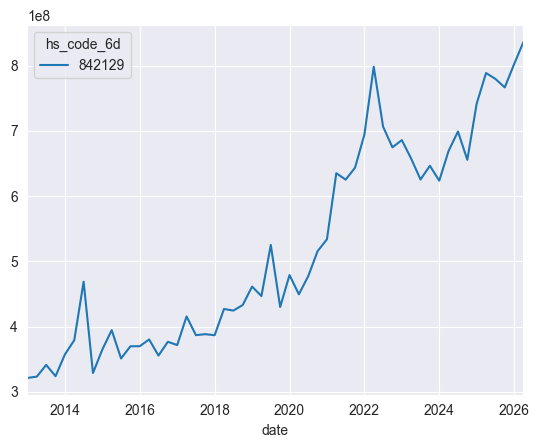

In [43]:
trade_pivot_df[['842129']].plot()

In [44]:
yoy_trade_growth[['842129']].tail(8)

hs_code_6d,842129
date,
2024-09-30,11.759439
2024-12-31,1.413350
2025-03-31,18.940233
2025-06-30,17.830895
2025-09-30,11.533735
2025-12-31,16.922737
2026-03-31,8.158313
2026-06-30,6.041152
